# Sleep Health and Lifestyle - Corrected EDA

This notebook uses the fixed cleaned dataset and resolves the earlier inconsistency where pandas interpreted **"None"** in the **Sleep Disorder** column as missing values.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the corrected dataset
# keep_default_na=False prevents the string "None" from being converted to NaN

df = pd.read_csv('sleep_health_lifestyle_dataset_fixed.csv', keep_default_na=False)

# Optional safety checks
# Ensure consistent categorical values

df['Sleep Disorder'] = df['Sleep Disorder'].replace({'': 'None'})
df['BMI Category'] = df['BMI Category'].replace({'Normal Weight': 'Normal'})

df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic_BP,Diastolic_BP
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,None,126,83
1,2,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,None,125,80
2,4,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90
3,6,Male,28,Software Engineer,5.9,4,30,8,Obese,85,3000,Insomnia,140,90
4,7,Male,29,Teacher,6.3,6,40,7,Obese,82,3500,Insomnia,140,90


## Data Cleaning Summary

- Preserved **"None"** in **Sleep Disorder** as text using `keep_default_na=False`.
- Standardized **BMI Category** values.
- Confirmed **Systolic_BP** and **Diastolic_BP** are numeric.
- Used the provided cleaned and deduplicated dataset for EDA.

In [2]:
print('Shape:', df.shape)

print('\nMissing values by column:')
print(df.isna().sum())

print('\nData types:')
print(df.dtypes)

Shape: (132, 14)

Missing values by column:
Person ID                  0
Gender                     0
Age                        0
Occupation                 0
Sleep Duration             0
Quality of Sleep           0
Physical Activity Level    0
Stress Level               0
BMI Category               0
Heart Rate                 0
Daily Steps                0
Sleep Disorder             0
Systolic_BP                0
Diastolic_BP               0
dtype: int64

Data types:
Person ID                    int64
Gender                      object
Age                          int64
Occupation                  object
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                object
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder              object
Systolic_BP                  int64
Diastolic_BP                 int64
dtype: object


In [3]:
print(df.info())
print(df.describe(include='all'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132 entries, 0 to 131
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                132 non-null    int64  
 1   Gender                   132 non-null    object 
 2   Age                      132 non-null    int64  
 3   Occupation               132 non-null    object 
 4   Sleep Duration           132 non-null    float64
 5   Quality of Sleep         132 non-null    int64  
 6   Physical Activity Level  132 non-null    int64  
 7   Stress Level             132 non-null    int64  
 8   BMI Category             132 non-null    object 
 9   Heart Rate               132 non-null    int64  
 10  Daily Steps              132 non-null    int64  
 11  Sleep Disorder           132 non-null    object 
 12  Systolic_BP              132 non-null    int64  
 13  Diastolic_BP             132 non-null    int64  
dtypes: float64(1), int64(9), o

In [4]:
print('Sleep Disorder value counts:')
print(df['Sleep Disorder'].value_counts(dropna=False))

print('\nBMI Category value counts:')
print(df['BMI Category'].value_counts(dropna=False))

Sleep Disorder value counts:
Sleep Disorder
None           73
Sleep Apnea    30
Insomnia       29
Name: count, dtype: int64

BMI Category value counts:
BMI Category
Normal        73
Overweight    52
Obese          7
Name: count, dtype: int64


## Visualizations

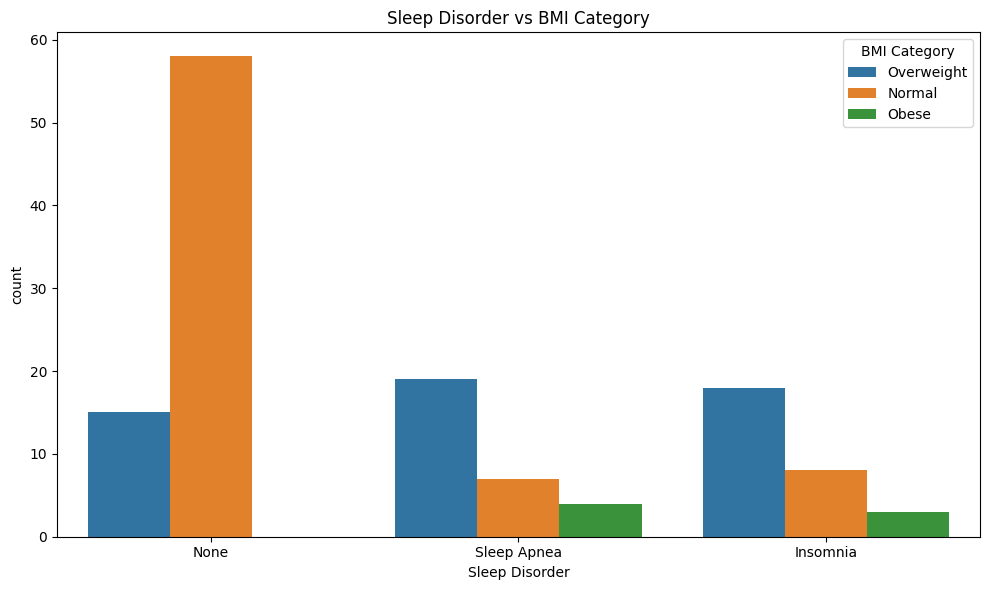

In [5]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Sleep Disorder', hue='BMI Category')
plt.title('Sleep Disorder vs BMI Category')
plt.tight_layout()
plt.show()

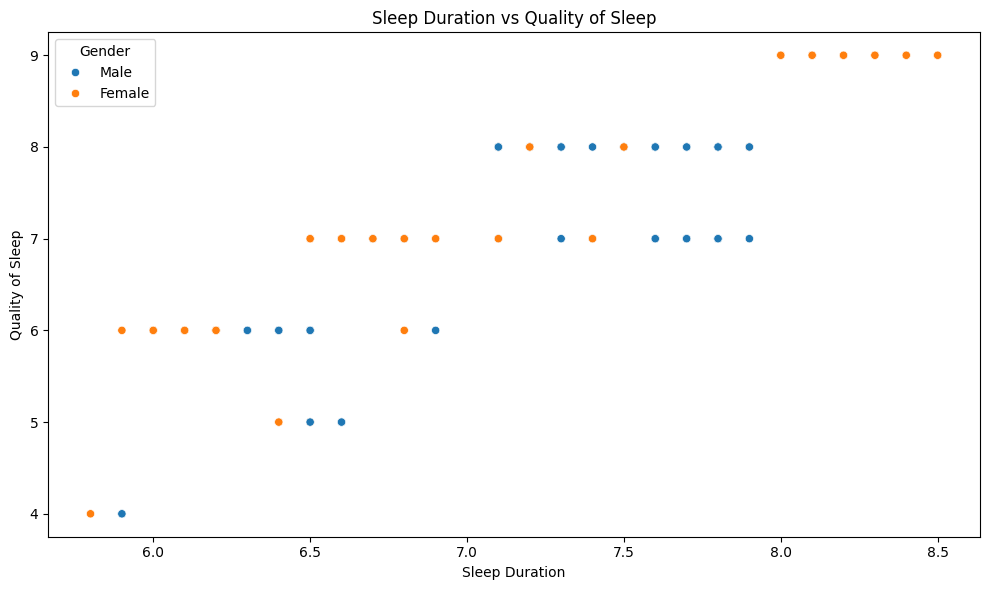

In [6]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Sleep Duration', y='Quality of Sleep', hue='Gender')
plt.title('Sleep Duration vs Quality of Sleep')
plt.tight_layout()
plt.show()

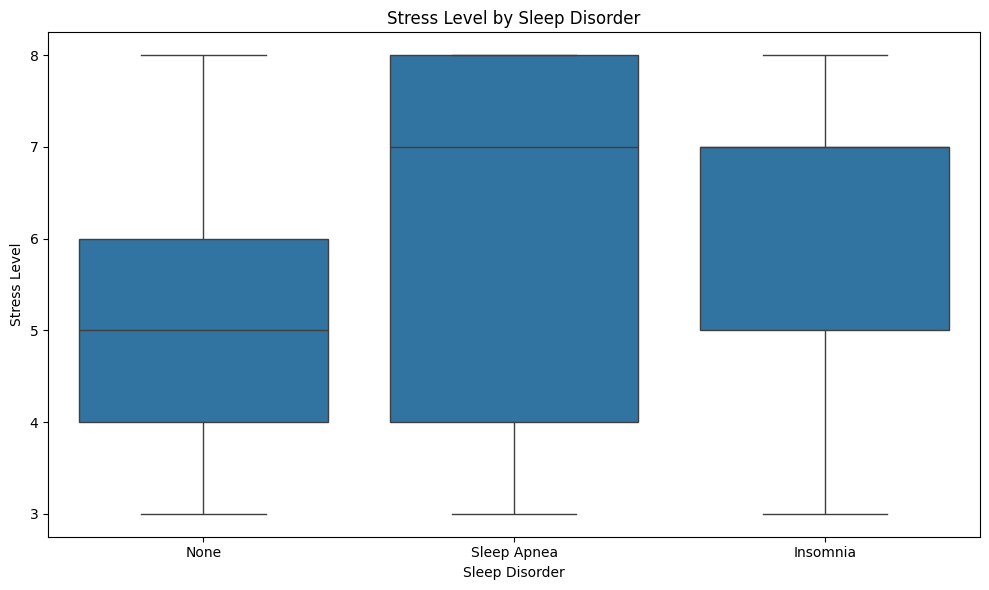

In [7]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Sleep Disorder', y='Stress Level')
plt.title('Stress Level by Sleep Disorder')
plt.tight_layout()
plt.show()

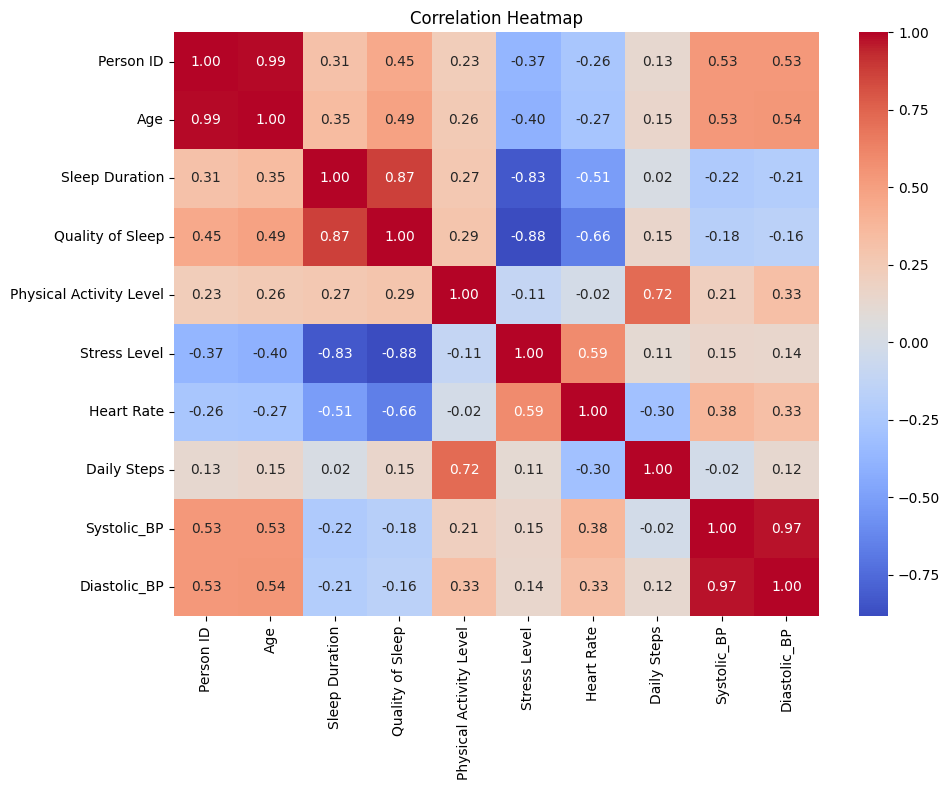

In [8]:
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()